In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
print(os.cpu_count())

144


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import random as rand
from statistics import mean, median,variance,stdev
import csv

from qulacs import QuantumState,QuantumCircuit, Observable, PauliOperator,ParametricQuantumCircuit,DensityMatrix, GeneralQuantumOperator
from qulacs.gate import H,X,Y,Z,RX,RY,RZ,CNOT,CZ,TOFFOLI,SWAP,merge,DenseMatrix,add, Probabilistic, P0, P1,to_matrix_gate,PauliRotation,Pauli, RandomUnitary
from qulacs.state import inner_product, partial_trace, tensor_product

# Quantum circuit

In [3]:
# observable
obsX = GeneralQuantumOperator(2)
obsX.add_operator( PauliOperator("X 0 X 1", 1.0) )

In [4]:
def random_initialize(params):
    for i in range(len(params)):
        params[i] = 2 * np.pi * rand.random()

In [ ]:
def my_update(self, params):
    
    for i in range(len(params)):
        self.set_parameter(i, params[i])

ParametricQuantumCircuit.my_update = my_update

In [5]:
# paulix stores the positions of X in the logical operator
# pauliy stores the positions of Y in the logical operator
# For example, XYZI is paulix=[1,0,1,0], pauliy=[0,1,1,0]
# Using this, when Pauli operators are represented as I=0, X=1, Y=2, Z=3, pauli can be written as pauli=paulix+2*pauliy
def add_block(n,circ,target,paulix,pauliy):
    stabx = np.array([1 for i in range(n)]) # XXX...X
    staby = np.array([1 for i in range(n)]) # YYY...Y
    
    pauli = paulix + 2*pauliy
    circ.add_parametric_multi_Pauli_rotation_gate(target, pauli, 0)
    #print("target = ",target, "pauli = ",pauli)
    
    pauli = (paulix + stabx)%2 + 2*pauliy
    circ.add_parametric_multi_Pauli_rotation_gate(target, pauli, 0)
    #print("target = ",target, "pauli = ",pauli)
    
    pauli = paulix + 2* ((pauliy + staby)%2)
    circ.add_parametric_multi_Pauli_rotation_gate(target, pauli, 0)
    #print("target = ",target, "pauli = ",pauli)
    
    pauli = (paulix + stabx)%2 + 2* ((pauliy + staby)%2)
    circ.add_parametric_multi_Pauli_rotation_gate(target, pauli, 0)
    #print("target = ",target, "pauli = ",pauli)
    
    return circ

In [6]:
# See section "Quantum circuits used in numerical experiments" in Methods of the paper
# n represents the number of qubits
# d represents the depth of the corresponding symmetric ansatz, where the number of rotation gates in the symmetric ansatz is L=d*n*/2.
# Each block of SLPA, which is constructed from a rotation gate of the symmetric ansatz, has four rotation gates. Therefore, the total number of rotation gates in SLPA is L=4*d*n*/2.
def make_circ_cbc(n, d):

    circ = ParametricQuantumCircuit(n)
    for i in range(d):
        k = i%6
        if k%2==0:
            for j in range(n//2):  
                mu = j + k//2
                target = range(n)
                paulix = np.zeros(n, dtype=np.int8)
                pauliy = np.zeros(n, dtype=np.int8)
                if mu%3==0: 
                    paulix[2*j] = 1
                    paulix[2*j+1] = 1
                elif mu%3==1:
                    pauliy[2*j] = 1
                    pauliy[2*j+1] = 1
                elif mu%3==2:
                    paulix[2*j] = 1
                    paulix[2*j+1] = 1
                    pauliy[2*j] = 1
                    pauliy[2*j+1] = 1    
                add_block(n,circ,target,paulix,pauliy)             
                
        if k%2==1:
            for j in range(n//2):  
                nu = j + (k-1)//2 + n//2
                target = range(n)
                paulix = np.zeros(n, dtype=np.int8)
                pauliy = np.zeros(n, dtype=np.int8)
                if nu%3==0: 
                    paulix[(2*j+1)%n] = 1
                    paulix[(2*j+2)%n] = 1
                elif nu%3==1:
                    pauliy[(2*j+1)%n] = 1
                    pauliy[(2*j+2)%n] = 1
                elif nu%3==2:
                    paulix[(2*j+1)%n] = 1
                    paulix[(2*j+2)%n] = 1
                    pauliy[(2*j+1)%n] = 1
                    pauliy[(2*j+2)%n] = 1    
                add_block(n,circ,target,paulix,pauliy)
                
    return circ

# Calculate variance

In [7]:
def cal_var_cbc(n, d, ns):
    num_params = 4 * d * n // 2
    params = np.zeros(num_params)
    random_initialize(params)
    
    circ = make_circ_cbc(n, d)
    
    results = []
    for _ in range(ns):
        random_initialize(params)
        circ.my_update(params)
        qstate = QuantumState(n)
        circ.update_quantum_state(qstate)
        results.append( np.real(obsX.get_expectation_value(qstate)) )
        
    var = variance(results)
    return var

# Statistics

In [ ]:
nqubits_list = [6,8,10,12,14]
depth_list = np.arange(6,80,2)
num_samp = 10000

for n in nqubits_list:
    var_list = []
    for d in depth_list:
        var_list.append( cal_var_cbc(n, d, num_samp) )

    with open(f'data2/cbc_n={n}_samp={num_samp}.csv', 'w') as f:
        writer = csv.writer(f)
        writer.writerow(depth_list)
        writer.writerow(var_list)

# Plots

In [9]:
# symmetric ansatz
ns = 10000

n=6
filename = f'data2/sc_n={n}_samp={ns}.csv'
sc_n6 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=8
filename = f'data2/sc_n={n}_samp={ns}.csv'
sc_n8 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=10
filename = f'data2/sc_n={n}_samp={ns}.csv'
sc_n10 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=12
filename = f'data2/sc_n={n}_samp={ns}.csv'
sc_n12 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=14
filename = f'data2/sc_n={n}_samp={ns}.csv'
sc_n14 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

In [10]:
# SLPA
ns = 10000

n=6
filename = f'data2/cbc_n={n}_samp={ns}.csv'
cbc_n6 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=8
filename = f'data2/cbc_n={n}_samp={ns}.csv'
cbc_n8 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=10
filename = f'data2/cbc_n={n}_samp={ns}.csv'
cbc_n10 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=12
filename = f'data2/cbc_n={n}_samp={ns}.csv'
cbc_n12 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

n=14
filename = f'data2/cbc_n={n}_samp={ns}.csv'
cbc_n14 = np.loadtxt(filename, delimiter=",", dtype=np.complex128)

/home/chinzei/venv_qulacs/env/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


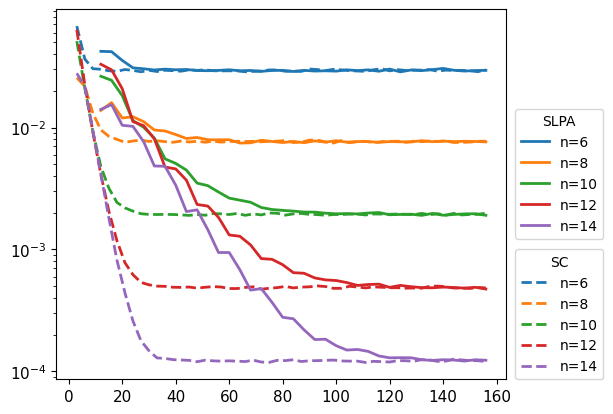

In [11]:
fig, ax = plt.subplots(figsize=(6,4))

# The horizontal axis is L/n, where L is the total number of rotation gates
# In the symmetric ansatz,L=d*n/2, thus L/n=d/2.
# In the SLPA, L=4*d*n/2, thus L/n=2*d.
ax.set_yscale('log')
ax.plot(sc_n6[0]/2,sc_n6[1], color='tab:blue', linestyle='dashed', linewidth=2, label='n=6')
ax.plot(sc_n8[0]/2,sc_n8[1], color='tab:orange', linestyle='dashed', linewidth=2, label='n=8')
ax.plot(sc_n10[0]/2,sc_n10[1], color='tab:green', linestyle='dashed', linewidth=2, label='n=10')
ax.plot(sc_n12[0]/2,sc_n12[1], color='tab:red', linestyle='dashed', linewidth=2, label='n=12')
ax.plot(sc_n14[0]/2,sc_n14[1], color='tab:purple', linestyle='dashed', linewidth=2, label='n=14')

ax.plot(2*cbc_n6[0],cbc_n6[1], color='tab:blue', linestyle='solid', linewidth=2, label='n=6')
ax.plot(2*cbc_n8[0],cbc_n8[1], color='tab:orange', linestyle='solid', linewidth=2, label='n=8')
ax.plot(2*cbc_n10[0],cbc_n10[1], color='tab:green', linestyle='solid', linewidth=2, label='n=10')
ax.plot(2*cbc_n12[0],cbc_n12[1], color='tab:red', linestyle='solid', linewidth=2, label='n=12')
ax.plot(2*cbc_n14[0],cbc_n14[1], color='tab:purple', linestyle='solid', linewidth=2, label='n=14')

hans, labs = ax.get_legend_handles_labels()
l1 = ax.legend(handles=hans[0:5], labels=labs[0:5],loc=(1.02,0), fontsize=10, title='SC')#y1の凡例
l2 = ax.legend(handles=hans[5:10], labels=labs[5:10],loc=(1.02,0.38), fontsize=10, title="SLPA")#y1の凡例
ax.add_artist(l1)

ax.tick_params(labelsize=11)

plt.subplots_adjust(left=0.08, right=0.83, bottom=0.07, top=0.995)
plt.savefig("barren_plateau.pdf")
plt.show()